## 1단계. 필요한 라이브러리 불러오기

이 단계에서는 실습에서 사용할 도구를 준비합니다.

- **파일 및 폴더 처리**: `os`, `glob`, `Path`, `shutil`
- **데이터 처리**: `numpy`, `pandas`
- **이미지 처리**: `PIL.Image`
- **그래프 출력**: `matplotlib`
- **데이터 분리와 라벨 변환**: `scikit-learn`
- **CNN 모델 생성 및 학습**: `TensorFlow/Keras`

아직 모델을 학습하는 단계는 아닙니다.  
오류 없이 실행되면 필요한 라이브러리가 정상적으로 준비된 것입니다.

In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================

# 운영체제와 관련된 기능을 사용하기 위해 os 모듈을 불러옵니다.
# 예: 폴더 경로 확인, 환경 변수 접근, 파일 시스템 작업
import os

# 파일이나 폴더를 복사·이동·삭제할 때 사용하는 shutil 모듈입니다.
# 현재 코드에서는 직접 사용되지 않지만 파일 정리에 활용할 수 있습니다.
import shutil

# 특정 규칙과 일치하는 파일 경로를 한꺼번에 찾기 위해 glob 모듈을 불러옵니다.
# 뒤에서 *.png, *.jpg 등의 이미지 경로를 찾을 때 사용합니다.
import glob

# 파일 경로를 객체 형태로 편리하게 다루기 위해 Path를 불러옵니다.
# 뒤에서 이미지의 부모 폴더 이름을 얻을 때 사용합니다.
from pathlib import Path

# NumPy를 np라는 짧은 이름으로 불러옵니다.
# 이미지를 숫자 배열로 변환하고 배열 모양을 바꾸는 데 사용합니다.
import numpy as np

# Pandas를 pd라는 짧은 이름으로 불러옵니다.
# 이미지 경로와 악성코드 패밀리를 표(DataFrame) 형태로 관리합니다.
import pandas as pd

# Matplotlib의 pyplot을 plt라는 이름으로 불러옵니다.
# 이미지, 정확도 그래프, 혼동행렬을 화면에 출력할 때 사용합니다.
import matplotlib.pyplot as plt

# Pillow 라이브러리의 Image 기능을 불러옵니다.
# 이미지 파일을 열고 흑백 변환 및 크기 조정을 할 때 사용합니다.
from PIL import Image

# 전체 데이터를 학습용과 평가용으로 나누는 함수를 불러옵니다.
from sklearn.model_selection import train_test_split

# 문자열 라벨을 0, 1, 2 같은 숫자로 변환하는 도구를 불러옵니다.
from sklearn.preprocessing import LabelEncoder

# classification_report는 Precision, Recall, F1-score를 계산합니다.
# confusion_matrix는 실제값과 예측값의 조합을 행렬로 만듭니다.
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow 전체 기능을 tf라는 짧은 이름으로 불러옵니다.
import tensorflow as tf

# layers는 Conv2D, MaxPooling2D, Dense 등의 신경망 층을 제공합니다.
# models는 여러 층을 연결해 모델을 구성하는 기능을 제공합니다.
from tensorflow.keras import layers, models


## 2단계. Malimg 데이터셋 다운로드

Malimg는 악성코드 파일의 바이트 데이터를 이미지로 표현한 데이터셋입니다.

같은 악성코드 패밀리는 코드 구조가 비슷하므로 이미지로 변환했을 때도 비슷한 무늬가 나타날 수 있습니다. CNN은 이러한 이미지 패턴을 학습합니다.

이 셀에서는 Kaggle에서 데이터셋을 다운로드하고 압축을 해제합니다.

> Kaggle API 인증이 되어 있지 않으면 다운로드 오류가 발생할 수 있습니다.

In [2]:
# ============================================================
# 3. Malimg 데이터셋 다운로드
# ============================================================

# Colab 또는 Jupyter에서 !로 시작하는 줄은 파이썬 코드가 아니라
# 운영체제의 셸 명령어를 실행한다는 뜻입니다.
# mkdir은 폴더를 만드는 명령어입니다.
# -p 옵션은 폴더가 이미 있어도 오류를 내지 않고,
# 필요한 상위 폴더도 함께 생성합니다.
# ./malimg_data는 현재 작업 위치 아래에 만들 폴더 이름입니다.
!mkdir -p ./malimg_data

# Malimg Original 데이터셋을 Kaggle에서 다운로드합니다.
# kaggle datasets download는 Kaggle 데이터셋 다운로드 명령입니다.
# -d ikrambenabd/malimg-original은 다운로드할 데이터셋의 고유 이름입니다.
# -p ./malimg_data는 다운로드할 저장 폴더를 지정합니다.
# --unzip은 다운로드 후 압축 파일을 자동으로 해제합니다.
!kaggle datasets download -d ikrambenabd/malimg-original -p ./malimg_data --unzip

# 데이터셋 다운로드 명령이 끝났음을 사용자가 확인할 수 있도록 문장을 출력합니다.
print("Malimg 데이터셋 다운로드 완료")


Dataset URL: https://www.kaggle.com/datasets/ikrambenabd/malimg-original
License(s): unknown
100% 1.09G/1.09G [00:12<00:00, 94.7MB/s]

Malimg 데이터셋 다운로드 완료


## 3단계. 이미지 파일 경로 수집

다운로드한 폴더에서 이미지 파일의 위치를 모두 찾습니다.

이 단계에서는 이미지 내용을 읽지 않고, 다음과 같은 **파일 경로만 수집**합니다.

`malimg_data/악성코드패밀리명/이미지파일.png`

이미지 수가 0으로 나오면 데이터 다운로드 및 압축 해제 경로를 확인해야 합니다.

In [3]:
# ============================================================
# 4. 이미지 파일 목록 확인
# ============================================================

# 발견한 모든 이미지 파일 경로를 저장할 빈 리스트를 만듭니다.
image_paths = []

# 찾고 싶은 이미지 확장자를 하나씩 ext 변수에 넣어 반복합니다.
# *.png는 파일 이름은 무엇이든 가능하고 확장자가 png인 파일을 뜻합니다.
for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp"]:

    # glob.glob()으로 현재 폴더와 모든 하위 폴더에서
    # 해당 확장자의 이미지 파일 경로를 찾습니다.
    # 찾은 여러 경로를 image_paths 리스트 뒤에 추가합니다.
    image_paths.extend(

        # "./malimg_data/**/"는 malimg_data 아래의 모든 하위 폴더를 뜻합니다.
        # + ext를 통해 현재 반복 중인 확장자 조건을 경로 뒤에 붙입니다.
        # recursive=True가 있어야 **가 모든 깊이의 하위 폴더를 탐색합니다.
        glob.glob("./malimg_data/**/" + ext, recursive=True)
    )

# image_paths에 저장된 파일 경로 개수를 출력합니다.
# len(image_paths)는 찾은 전체 이미지 파일 수입니다.
print("전체 이미지 수:", len(image_paths))

# 예시 경로 출력 전에 줄을 한 번 띄우고 제목을 표시합니다.
# 문자열 앞의 \n은 줄바꿈 문자입니다.
print("\n예시 파일 경로:")

# image_paths[:10]은 전체 경로 중 앞의 10개만 가져옵니다.
# 경로가 10개보다 적으면 존재하는 만큼만 반복합니다.
for p in image_paths[:10]:

    # 현재 반복에서 p에 들어 있는 이미지 파일 경로를 출력합니다.
    print(p)


전체 이미지 수: 9339

예시 파일 경로:
./malimg_data/malimg_paper_dataset_imgs/VB.AT/00a6793a16eec2fac4d673cde7df660b.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/0623b494c5e45a95c03793decce74fee.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/00e73efc1f3d723b259fc3a19656f306.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/024220e36fcda6c98e23f84633e8f049.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/000386761524b7b36f065fdb69365dca.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/066918b802f57a9b08d68badb5d1da6f.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/088ec4ae5db8e54fc56ec88e30a68cf1.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/03987e64d47e94d2c61562fe62208e70.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/046f1b08f15b1a4ee455e81f4ad2311f.png
./malimg_data/malimg_paper_dataset_imgs/VB.AT/0696522b65c8c501fea3050651002fd1.png


## 4단계. 이미지 경로와 정답 라벨 연결

CNN을 지도학습으로 학습하려면 각 이미지의 정답이 필요합니다.

Malimg 데이터셋은 일반적으로 악성코드 패밀리별 폴더로 이미지가 구분되어 있습니다. 따라서 이미지의 **부모 폴더 이름**을 정답 라벨로 사용합니다.

결과는 다음 두 열을 가진 표로 만들어집니다.

- `image_path`: 이미지 파일 위치
- `family`: 악성코드 패밀리 이름

In [4]:
# ============================================================
# 5. 이미지 경로와 악성코드 패밀리 Label 구성
# ============================================================

# 이미지 경로와 패밀리 이름을 딕셔너리 형태로 모아둘 빈 리스트입니다.
data = []

# 앞에서 찾은 이미지 경로를 하나씩 path 변수에 넣어 반복합니다.
for path in image_paths:

    # Path(path)는 문자열 경로를 Path 객체로 바꿉니다.
    # .parent는 이미지가 들어 있는 바로 위의 부모 폴더를 의미합니다.
    # .name은 부모 폴더 경로 중 마지막 폴더 이름만 가져옵니다.
    # Malimg에서는 이 부모 폴더 이름을 악성코드 패밀리 정답으로 사용합니다.
    family = Path(path).parent.name

    # 현재 이미지의 경로와 패밀리 이름을 하나의 딕셔너리로 묶습니다.
    # 이 딕셔너리를 data 리스트 뒤에 추가합니다.
    data.append({

        # image_path 열에 현재 이미지 파일 경로를 저장합니다.
        "image_path": path,

        # family 열에 현재 이미지의 악성코드 패밀리 이름을 저장합니다.
        "family": family
    })

# 딕셔너리 리스트인 data를 Pandas DataFrame 표로 변환합니다.
# 결과적으로 image_path와 family 두 개의 열을 가진 표가 만들어집니다.
df_img = pd.DataFrame(data)

# 이미지 메타데이터 표 생성이 끝났다는 문장을 출력합니다.
print("이미지 메타데이터 생성 완료")

# df_img.shape는 (행 개수, 열 개수)를 반환합니다.
# 행 개수는 이미지 수이고 열 개수는 현재 2개입니다.
print("데이터 크기:", df_img.shape)

# 패밀리 분포 출력 전에 줄을 한 번 띄우고 제목을 표시합니다.
print("\n패밀리 분포 상위 10개:")

# df_img["family"]는 family 열만 선택합니다.
# value_counts()는 패밀리별 등장 횟수를 많은 순서로 계산합니다.
# head(10)은 상위 10개 결과만 가져옵니다.
print(df_img["family"].value_counts().head(10))

# DataFrame의 앞부분 5행을 표 형태로 표시합니다.
# display는 Jupyter/Colab에서 보기 좋은 표로 출력합니다.
display(df_img.head())


이미지 메타데이터 생성 완료
데이터 크기: (9339, 2)

패밀리 분포 상위 10개:
family
Allaple.A        2949
Allaple.L        1591
Yuner.A           800
Instantaccess     431
VB.AT             408
Fakerean          381
Lolyda.AA1        213
C2LOP.gen!g       200
Alueron.gen!J     198
Lolyda.AA2        184
Name: count, dtype: int64


,image_path,family
0,./malimg_data/malimg_paper_dataset_imgs/VB.AT/...,VB.AT
1,./malimg_data/malimg_paper_dataset_imgs/VB.AT/...,VB.AT
2,./malimg_data/malimg_paper_dataset_imgs/VB.AT/...,VB.AT
3,./malimg_data/malimg_paper_dataset_imgs/VB.AT/...,VB.AT
4,./malimg_data/malimg_paper_dataset_imgs/VB.AT/...,VB.AT


## 5단계. 사용할 악성코드 패밀리와 이미지 선택

전체 데이터를 모두 사용하면 초보자 실습 환경에서는 학습 시간이 길어질 수 있습니다.

따라서 이미지 수가 많은 상위 5개 패밀리를 선택하고, 각 패밀리에서 최대 200장씩 사용합니다.

패밀리별 데이터 수를 비슷하게 맞추면 특정 패밀리만 지나치게 많이 학습되는 문제를 줄일 수 있습니다.

In [5]:
# ============================================================
# 6. 상위 5개 악성코드 패밀리에서 총 1,000장 샘플링
# ============================================================

# family 열에서 패밀리별 이미지 수를 계산합니다.
# head(5)로 이미지 수가 가장 많은 상위 5개 패밀리만 선택합니다.
# .index는 패밀리 이름 부분만 가져옵니다.
# .tolist()는 결과를 일반 파이썬 리스트로 변환합니다.
top_families = df_img["family"].value_counts().head(5).index.tolist()

# 선택된 상위 5개 패밀리라는 제목을 출력합니다.
print("선택된 상위 5개 패밀리:")

# top_families 리스트에 들어 있는 실제 패밀리 이름을 출력합니다.
print(top_families)

# 각 패밀리에서 최대 몇 장을 선택할지 정합니다.
# 여기서는 패밀리당 최대 200장을 사용합니다.
sample_per_family = 200

# 패밀리별로 추출한 DataFrame을 저장할 빈 리스트입니다.
sample_list = []

# 상위 5개 패밀리 이름을 하나씩 family 변수에 넣어 반복합니다.
for family in top_families:

    # df_img["family"] == family는 현재 패밀리와 같은 행만 True가 됩니다.
    # df_img[...]로 True인 행만 선택해 현재 패밀리의 데이터만 가져옵니다.
    # .copy()는 원본과 분리된 복사본을 만들어 경고나 의도치 않은 변경을 방지합니다.
    temp = df_img[df_img["family"] == family].copy()

    # 현재 패밀리 데이터에서 무작위 표본을 선택합니다.
    temp_sample = temp.sample(

        # n은 뽑을 행의 개수입니다.
        # min(200, len(temp))를 사용하므로 이미지가 200장 이상이면 200장,
        # 200장보다 적으면 현재 가진 이미지 수만큼만 선택합니다.
        n=min(sample_per_family, len(temp)),

        # random_state=42는 난수 결과를 고정합니다.
        # 코드를 다시 실행해도 같은 이미지가 선택됩니다.
        random_state=42
    )

    # 현재 패밀리에서 뽑은 표본을 sample_list 뒤에 추가합니다.
    sample_list.append(temp_sample)

# sample_list 안의 여러 DataFrame을 세로 방향으로 하나로 합칩니다.
# ignore_index=True는 기존 행 번호를 버리고 0부터 새 번호를 부여합니다.
df_sample = pd.concat(sample_list, ignore_index=True)

# frac=1은 전체 행의 100%를 무작위 순서로 다시 뽑는다는 뜻입니다.
# 즉, 패밀리별로 모여 있는 행 순서를 전체적으로 섞습니다.
# random_state=42로 섞인 순서도 재현 가능하게 고정합니다.
# reset_index(drop=True)는 섞기 전 인덱스를 버리고 0부터 다시 번호를 부여합니다.
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# 최종 교육용 샘플 표의 행과 열 개수를 출력합니다.
print("교육용 샘플 데이터 크기:", df_sample.shape)

# 패밀리별 샘플 수 출력 전에 줄을 한 번 띄우고 제목을 표시합니다.
print("\n샘플 패밀리 분포:")

# 샘플 데이터에서 패밀리별 이미지 개수를 계산해 출력합니다.
print(df_sample["family"].value_counts())

# 최종 샘플 DataFrame의 앞부분 5행을 표로 확인합니다.
display(df_sample.head())


선택된 상위 5개 패밀리:
['Allaple.A', 'Allaple.L', 'Yuner.A', 'Instantaccess', 'VB.AT']
교육용 샘플 데이터 크기: (1000, 2)

샘플 패밀리 분포:
family
Yuner.A          200
Instantaccess    200
VB.AT            200
Allaple.A        200
Allaple.L        200
Name: count, dtype: int64


,image_path,family
0,./malimg_data/malimg_paper_dataset_imgs/Yuner....,Yuner.A
1,./malimg_data/malimg_paper_dataset_imgs/Instan...,Instantaccess
2,./malimg_data/malimg_paper_dataset_imgs/Instan...,Instantaccess
3,./malimg_data/malimg_paper_dataset_imgs/Instan...,Instantaccess
4,./malimg_data/malimg_paper_dataset_imgs/Yuner....,Yuner.A


## 6단계. 이미지 전처리

크기와 형식이 다른 이미지를 CNN에 그대로 넣을 수는 없습니다.

각 이미지에 다음 작업을 적용합니다.

1. 이미지 파일 열기
2. 흑백 이미지로 변환
3. 크기를 64×64로 통일
4. 픽셀값을 0~255에서 0~1로 정규화
5. CNN 입력 형태인 `(개수, 높이, 너비, 채널)`로 변환

흑백 이미지이므로 채널 수는 1입니다.

In [6]:
# ============================================================
# 7. 이미지 불러오기 및 전처리
# ============================================================

# 모든 이미지를 가로 64픽셀, 세로 64픽셀로 통일하기 위한 크기입니다.
IMG_SIZE = 64

# 이미지 경로 하나를 입력받아 전처리된 배열을 반환하는 함수를 정의합니다.
def load_image(path):

    # Image.open(path)로 이미지 파일을 엽니다.
    # convert("L")은 이미지를 흑백 1채널 형식으로 변환합니다.
    img = Image.open(path).convert("L")

    # 이미지 크기를 64×64로 통일합니다.
    # CNN에는 같은 크기의 이미지들이 입력되어야 합니다.
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Pillow 이미지를 NumPy 숫자 배열로 변환합니다.
    # 원래 픽셀값은 일반적으로 0~255 범위입니다.
    # 255.0으로 나누어 0~1 범위로 정규화합니다.
    arr = np.array(img) / 255.0

    # 전처리가 끝난 2차원 이미지 배열을 함수 밖으로 반환합니다.
    return arr


# 전처리된 이미지 배열을 차례대로 저장할 빈 리스트입니다.
X_images = []

# 각 이미지에 대응하는 악성코드 패밀리 이름을 저장할 빈 리스트입니다.
y_labels = []

# df_sample의 각 행을 한 줄씩 반복합니다.
# idx에는 행 번호가 들어가고 row에는 해당 행의 데이터가 들어갑니다.
for idx, row in df_sample.iterrows():

    # 이미지 파일 오류가 있더라도 전체 반복이 중단되지 않도록 예외 처리를 시작합니다.
    try:

        # 현재 행의 image_path 값을 load_image 함수에 전달합니다.
        # 반환된 64×64 정규화 배열을 img_arr에 저장합니다.
        img_arr = load_image(row["image_path"])

        # 전처리된 이미지 배열을 X_images 리스트에 추가합니다.
        X_images.append(img_arr)

        # 현재 이미지의 악성코드 패밀리 이름을 y_labels에 추가합니다.
        y_labels.append(row["family"])

    # 이미지 파일이 손상되었거나 열리지 않으면 발생한 오류를 e에 저장합니다.
    except Exception as e:

        # 실패한 이미지 경로와 오류 내용을 출력하고 다음 이미지로 넘어갑니다.
        print("이미지 로드 실패:", row["image_path"], e)

# 이미지 배열 리스트를 하나의 NumPy 배열로 변환합니다.
# 변환 직후 모양은 일반적으로 (이미지 수, 64, 64)입니다.
X_images = np.array(X_images)

# CNN 입력 형식에 맞게 배열 모양을 변경합니다.
# -1은 이미지 개수를 자동으로 계산하라는 뜻입니다.
# IMG_SIZE, IMG_SIZE는 이미지 높이와 너비입니다.
# 마지막 1은 흑백 이미지의 채널 수입니다.
X_images = X_images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# 문자열 패밀리 이름 리스트도 NumPy 배열로 변환합니다.
y_labels = np.array(y_labels)

# 최종 CNN 입력 이미지 배열의 모양을 출력합니다.
# 결과 형식: (이미지 수, 64, 64, 1)
print("이미지 배열 크기:", X_images.shape)

# 전처리에 성공한 이미지와 연결된 라벨 개수를 출력합니다.
print("Label 개수:", len(y_labels))


이미지 배열 크기: (1000, 64, 64, 1)
Label 개수: 1000


## 7단계. 패밀리 이름을 숫자로 변환

신경망은 `Allaple.A` 같은 문자열보다 0, 1, 2 형태의 숫자 정답을 사용하기 편합니다.

`LabelEncoder`를 사용해 각 악성코드 패밀리 이름에 숫자 번호를 부여합니다.

이 번호는 위험도나 순위를 의미하지 않고, 단순히 클래스를 구분하기 위한 값입니다.

In [7]:
# ============================================================
# 8. Label 숫자 변환
# ============================================================

# 문자열 패밀리 이름을 숫자로 바꾸기 위한 LabelEncoder 객체를 생성합니다.
label_encoder = LabelEncoder()

# fit_transform은 두 작업을 한 번에 수행합니다.
# fit: y_labels에 어떤 패밀리들이 있는지 학습합니다.
# transform: 각 패밀리 이름을 0, 1, 2 같은 숫자로 변환합니다.
# 변환된 숫자 라벨 배열을 y에 저장합니다.
y = label_encoder.fit_transform(y_labels)

# classes_에는 숫자 라벨과 연결된 원래 패밀리 이름들이 저장됩니다.
# 예를 들어 class_names[0]은 숫자 0에 해당하는 패밀리 이름입니다.
class_names = label_encoder.classes_

# 클래스 목록을 출력하기 위한 제목입니다.
print("클래스 목록:")

# 실제 악성코드 패밀리 이름 목록을 출력합니다.
print(class_names)

# 클래스 수를 출력하기 전에 한 줄을 띄우고 제목을 표시합니다.
print("\n클래스 수:", len(class_names))


클래스 목록:
['Allaple.A' 'Allaple.L' 'Instantaccess' 'VB.AT' 'Yuner.A']

클래스 수: 5


## 8단계. 학습 데이터와 평가 데이터 분리

전체 데이터를 다음과 같이 나눕니다.

- **학습 데이터**: 모델이 이미지 패턴을 배우는 데 사용
- **평가 데이터**: 학습 후 새로운 데이터에 대한 성능 확인

전체 데이터의 80%는 학습용, 20%는 평가용으로 사용합니다.

`stratify=y`를 사용하면 각 패밀리 비율이 두 데이터에 비슷하게 유지됩니다.

In [8]:
# ============================================================
# 9. 학습 데이터와 평가 데이터 분리
# ============================================================

# 전체 이미지와 라벨을 학습용과 평가용으로 나눕니다.
# 함수는 X_train, X_test, y_train, y_test 네 결과를 반환합니다.
X_train, X_test, y_train, y_test = train_test_split(

    # 분리할 전체 이미지 데이터입니다.
    X_images,

    # 각 이미지에 대응하는 숫자 정답 라벨입니다.
    y,

    # 전체 데이터의 20%를 평가 데이터로 사용합니다.
    # 나머지 80%는 학습 데이터가 됩니다.
    test_size=0.2,

    # 데이터 분리 결과를 고정해 다시 실행해도 같은 데이터가 나뉘도록 합니다.
    random_state=42,

    # 전체 데이터의 클래스 비율이 학습·평가 데이터에도 비슷하게 유지되도록 합니다.
    stratify=y
)

# 학습 이미지 배열의 모양을 출력합니다.
# 형식: (학습 이미지 수, 64, 64, 1)
print("학습 데이터:", X_train.shape)

# 평가 이미지 배열의 모양을 출력합니다.
# 형식: (평가 이미지 수, 64, 64, 1)
print("평가 데이터:", X_test.shape)


학습 데이터: (800, 64, 64, 1)
평가 데이터: (200, 64, 64, 1)


## 9단계. 전처리된 이미지 확인

전처리된 이미지와 정답 패밀리를 직접 화면에 출력합니다.

이 단계는 모델 학습 전에 다음을 확인하기 위한 과정입니다.

- 이미지가 정상적으로 열렸는가?
- 흑백 변환과 크기 변경이 적용되었는가?
- 이미지와 정답 패밀리가 올바르게 연결되었는가?

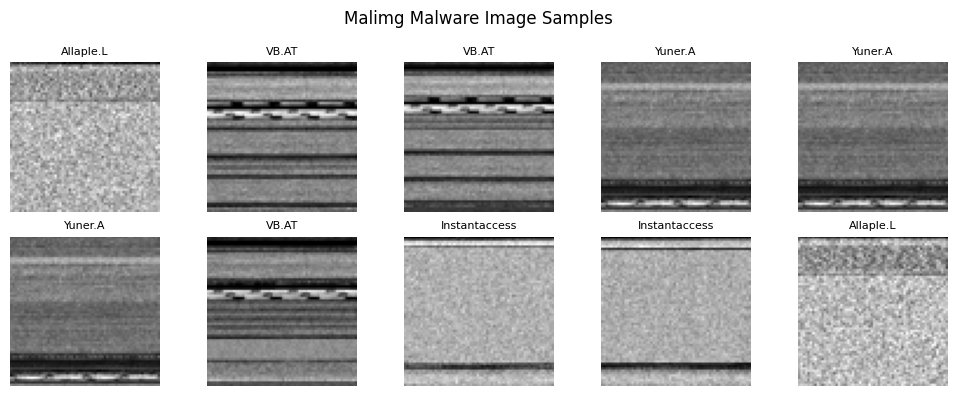

In [9]:
# ============================================================
# 10. 이미지 샘플 시각화
# ============================================================

# 전체 그림판 크기를 가로 10인치, 세로 4인치로 설정합니다.
plt.figure(figsize=(10, 4))

# 학습 데이터의 앞쪽 이미지 10장을 화면에 출력하기 위해 0부터 9까지 반복합니다.
for i in range(10):

    # 2행 5열의 작은 그래프 영역 중 i+1번째 위치를 선택합니다.
    # subplot 위치 번호는 1부터 시작하므로 i가 아니라 i+1을 사용합니다.
    plt.subplot(2, 5, i + 1)

    # X_train[i]는 (64, 64, 1) 모양입니다.
    # 화면 출력용으로 마지막 채널 차원을 제거해 (64, 64)로 바꿉니다.
    # cmap="gray"는 흑백 색상표로 이미지를 보여줍니다.
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")

    # y_train[i]는 숫자 라벨입니다.
    # class_names[...]를 이용해 숫자를 원래 패밀리 이름으로 변환합니다.
    # fontsize=8은 제목 글자 크기를 8로 설정합니다.
    plt.title(class_names[y_train[i]], fontsize=8)

    # 이미지 주변의 x축과 y축 눈금 및 테두리 표시를 숨깁니다.
    plt.axis("off")

# 전체 10개 이미지 위에 공통 제목을 표시합니다.
plt.suptitle("Malimg Malware Image Samples")

# 제목이나 이미지가 서로 겹치지 않도록 자동으로 여백을 조정합니다.
plt.tight_layout()

# 완성된 그림을 화면에 출력합니다.
plt.show()


## 10단계. CNN 모델 구성

CNN은 크게 두 부분으로 구성됩니다.

### 특징 추출 부분

- `Conv2D`: 이미지에서 선, 경계, 질감, 반복 무늬 등의 특징을 찾습니다.
- `MaxPooling2D`: 중요한 특징을 유지하면서 특징 지도의 크기를 줄입니다.

### 분류 부분

- `Flatten`: 2차원 특징 지도를 1차원 벡터로 펼칩니다.
- `Dense`: 추출된 특징을 이용해 악성코드 패밀리를 판단합니다.
- `Dropout`: 과대적합을 줄입니다.
- `Softmax`: 각 패밀리에 속할 확률을 출력합니다.

In [10]:
# ============================================================
# 11. CNN 모델 구성
# ============================================================

# 최종 분류해야 하는 악성코드 패밀리 개수를 계산합니다.
# 마지막 출력층의 뉴런 수로 사용됩니다.
num_classes = len(class_names)

# Sequential은 위에서 아래 순서대로 층을 통과하는 신경망 모델입니다.
model = models.Sequential([

    # 모델에 들어오는 이미지 한 장의 모양을 지정합니다.
    # 높이 64, 너비 64, 흑백 채널 1개입니다.
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # 첫 번째 합성곱층입니다.
    # 32: 서로 다른 특징을 찾는 필터를 32개 사용합니다.
    # (3, 3): 각 필터가 한 번에 보는 영역은 3×3입니다.
    # activation="relu": 음수 출력은 0으로 만들고 양수는 유지합니다.
    layers.Conv2D(32, (3, 3), activation="relu"),

    # 첫 번째 최대 풀링층입니다.
    # (2, 2) 영역마다 가장 큰 값만 남겨 가로와 세로 크기를 줄입니다.
    layers.MaxPooling2D((2, 2)),

    # 두 번째 합성곱층입니다.
    # 앞 층에서 찾은 기초 특징을 조합해 더 복잡한 특징을 찾습니다.
    # 필터 수를 64개로 늘립니다.
    layers.Conv2D(64, (3, 3), activation="relu"),

    # 두 번째 최대 풀링층입니다.
    # 특징 지도 크기를 다시 줄여 계산량을 감소시킵니다.
    layers.MaxPooling2D((2, 2)),

    # 여러 장의 2차원 특징 지도를 하나의 긴 1차원 벡터로 펼칩니다.
    # Dense 층에 전달하기 위한 형태 변환입니다.
    layers.Flatten(),

    # 128개의 뉴런을 가진 완전연결층입니다.
    # 앞에서 추출된 여러 특징을 종합해 클래스 판단에 필요한 표현을 학습합니다.
    layers.Dense(128, activation="relu"),

    # 학습할 때 뉴런의 30%를 무작위로 잠시 끕니다.
    # 특정 학습 데이터에 지나치게 맞춰지는 과대적합을 줄입니다.
    layers.Dropout(0.3),

    # 최종 출력층입니다.
    # 뉴런 수는 악성코드 패밀리 개수와 같습니다.
    # softmax는 각 패밀리에 속할 확률을 계산합니다.
    layers.Dense(num_classes, activation="softmax")
])

# 모델이 어떤 방식으로 학습할지 설정합니다.
model.compile(

    # Adam은 손실이 줄어들도록 각 가중치를 업데이트하는 최적화 알고리즘입니다.
    optimizer="adam",

    # 정답이 0, 1, 2 같은 정수이고 클래스가 여러 개인 분류 문제이므로
    # sparse_categorical_crossentropy 손실 함수를 사용합니다.
    loss="sparse_categorical_crossentropy",

    # 학습 과정에서 손실뿐 아니라 정확도도 함께 계산해 출력합니다.
    metrics=["accuracy"]
)

# 모델을 구성하는 각 층의 출력 모양과 학습 파라미터 수를 표로 출력합니다.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,221 (6.20 MB)

 Trainable params: 1,625,221 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

## 11단계. CNN 모델 학습

학습 과정은 다음과 같습니다.

1. 이미지 묶음을 모델에 입력
2. 모델이 악성코드 패밀리를 예측
3. 실제 정답과 예측의 차이인 손실 계산
4. 역전파를 통해 모델 가중치 수정
5. 전체 데이터를 여러 번 반복 학습

`epochs=5`는 전체 학습 데이터를 5번 반복한다는 뜻입니다.  
`batch_size=32`는 이미지를 한 번에 32장씩 처리한다는 뜻입니다.

In [11]:
# ============================================================
# 12. CNN 모델 학습
# CPU 환경 고려: epochs=5
# ============================================================

# model.fit은 준비한 학습 데이터로 CNN 모델을 실제 학습시킵니다.
# 학습 과정의 손실과 정확도 기록은 history 변수에 저장됩니다.
history = model.fit(

    # 모델에 입력할 학습 이미지 배열입니다.
    X_train,

    # 각 학습 이미지의 실제 정답 숫자 라벨입니다.
    y_train,

    # 전체 학습 데이터를 처음부터 끝까지 5번 반복 학습합니다.
    epochs=5,

    # 이미지 32장씩 한 묶음으로 나누어 가중치를 한 번 업데이트합니다.
    batch_size=32,

    # 학습 데이터의 20%를 검증용으로 따로 사용합니다.
    # 검증 데이터는 가중치 업데이트에는 직접 사용하지 않고
    # 각 epoch가 끝날 때 일반화 성능을 확인하는 데 사용합니다.
    validation_split=0.2
)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.5141 - loss: 1.2730 - val_accuracy: 0.7750 - val_loss: 0.5872
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.8313 - loss: 0.4104 - val_accuracy: 0.9000 - val_loss: 0.2362
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.8938 - loss: 0.2360 - val_accuracy: 0.8188 - val_loss: 0.2919
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.9328 - loss: 0.1802 - val_accuracy: 0.9875 - val_loss: 0.1138
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.9766 - loss: 0.0908 - val_accuracy: 0.9688 - val_loss: 0.0803


## 12단계. 학습 정확도 그래프 확인

학습 데이터 정확도와 검증 데이터 정확도를 함께 확인합니다.

- 두 정확도가 함께 상승하면 일반적으로 학습이 잘 진행된 것입니다.
- 학습 정확도만 높아지고 검증 정확도가 낮아지면 과대적합을 의심할 수 있습니다.

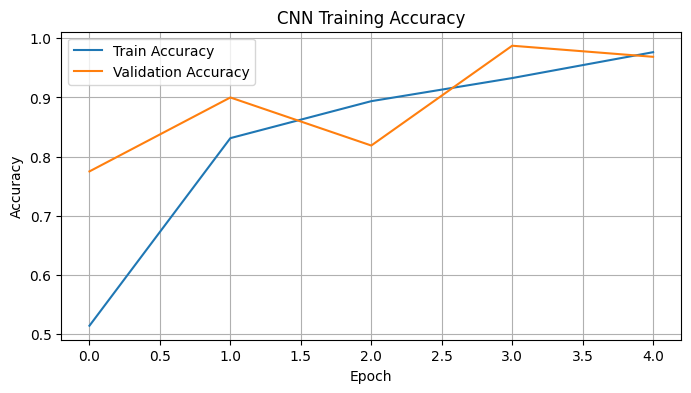

In [12]:
# ============================================================
# 13. 학습 정확도 시각화
# ============================================================

# 정확도 그래프를 그릴 새 그림판을 생성합니다.
# 가로 8인치, 세로 4인치 크기입니다.
plt.figure(figsize=(8, 4))

# history.history["accuracy"]에는 epoch별 학습 정확도가 저장되어 있습니다.
# label은 범례에 표시할 선의 이름입니다.
plt.plot(history.history["accuracy"], label="Train Accuracy")

# history.history["val_accuracy"]에는 epoch별 검증 정확도가 저장되어 있습니다.
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# 그래프 가로축 이름을 Epoch로 설정합니다.
plt.xlabel("Epoch")

# 그래프 세로축 이름을 Accuracy로 설정합니다.
plt.ylabel("Accuracy")

# 그래프 상단 제목을 설정합니다.
plt.title("CNN Training Accuracy")

# 각 선이 무엇을 뜻하는지 보여주는 범례를 표시합니다.
plt.legend()

# 값을 읽기 쉽도록 그래프 배경에 격자선을 표시합니다.
plt.grid(True)

# 완성된 정확도 그래프를 화면에 출력합니다.
plt.show()


## 13단계. 테스트 데이터로 최종 평가

모델이 학습 중 사용하지 않은 테스트 데이터를 이용해 최종 성능을 확인합니다.

- **Loss**: 예측과 실제 정답 사이의 오차
- **Accuracy**: 전체 이미지 중 올바르게 분류한 비율

예를 들어 정확도가 0.90이면 테스트 이미지의 약 90%를 맞힌 것입니다.

In [13]:
# ============================================================
# 14. 평가 데이터 성능 확인
# ============================================================

# 학습에 사용하지 않은 X_test와 y_test로 모델을 평가합니다.
# model.evaluate는 손실과 정확도를 반환합니다.
# 반환된 손실은 test_loss, 정확도는 test_acc에 저장합니다.
test_loss, test_acc = model.evaluate(X_test, y_test)

# test_loss를 소수점 넷째 자리까지 반올림해 출력합니다.
print("평가 Loss:", round(test_loss, 4))

# test_acc를 소수점 넷째 자리까지 반올림해 출력합니다.
# 예를 들어 0.95라면 전체 평가 이미지의 약 95%를 맞힌 것입니다.
print("평가 Accuracy:", round(test_acc, 4))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9800 - loss: 0.0608
평가 Loss: 0.0608
평가 Accuracy: 0.98


## 14단계. 클래스별 상세 평가지표 확인

전체 정확도만으로는 각 패밀리별 성능을 알기 어렵습니다.

`classification_report`에서 다음 지표를 확인합니다.

- **Precision**: 해당 패밀리라고 예측한 것 중 실제로 맞은 비율
- **Recall**: 실제 해당 패밀리 중 모델이 찾아낸 비율
- **F1-score**: Precision과 Recall을 함께 반영한 점수
- **Support**: 평가 데이터에 포함된 실제 이미지 수

In [14]:
# ============================================================
# 15. Classification Report
# ============================================================

# 평가 이미지 각각에 대해 모든 클래스의 예측 확률을 계산합니다.
# y_prob의 한 행에는 한 이미지의 클래스별 확률이 들어 있습니다.
y_prob = model.predict(X_test)

# axis=1은 각 이미지의 클래스 확률들 중 가장 큰 값의 위치를 찾는다는 뜻입니다.
# 가장 큰 확률의 위치가 최종 예측 클래스 번호가 됩니다.
y_pred = np.argmax(y_prob, axis=1)

# 실제 정답 y_test와 예측값 y_pred를 비교해
# 클래스별 Precision, Recall, F1-score, Support를 계산합니다.
print(classification_report(

    # 평가 이미지의 실제 숫자 라벨입니다.
    y_test,

    # 모델이 예측한 숫자 라벨입니다.
    y_pred,

    # 숫자 0, 1, 2 대신 실제 패밀리 이름이 보고서에 표시되도록 합니다.
    target_names=class_names
))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
               precision    recall  f1-score   support

    Allaple.A       0.91      1.00      0.95        40
    Allaple.L       1.00      0.90      0.95        40
Instantaccess       1.00      1.00      1.00        40
        VB.AT       1.00      1.00      1.00        40
      Yuner.A       1.00      1.00      1.00        40

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



## 15단계. 혼동행렬 확인

혼동행렬은 실제 패밀리와 예측 패밀리를 표 형태로 비교합니다.

- 세로축: 실제 패밀리
- 가로축: 예측 패밀리
- 대각선: 올바르게 분류한 개수
- 대각선 밖: 다른 패밀리로 잘못 분류한 개수

이를 통해 모델이 어떤 악성코드 패밀리끼리 자주 혼동하는지 확인할 수 있습니다.

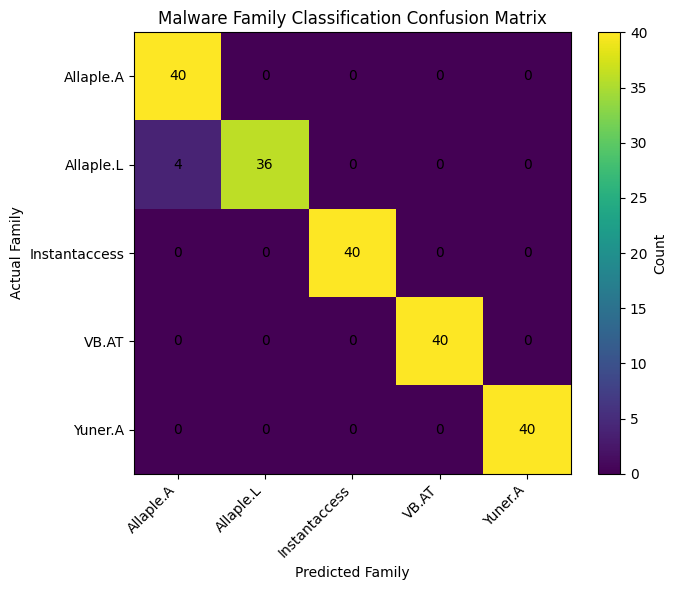

In [15]:
# ============================================================
# 16. Confusion Matrix 시각화
# ============================================================

# 실제 라벨과 예측 라벨을 비교해 혼동행렬을 계산합니다.
# 행은 실제 클래스, 열은 예측 클래스를 의미합니다.
cm = confusion_matrix(y_test, y_pred)

# 혼동행렬을 표시할 새 그림판을 만듭니다.
# 가로 7인치, 세로 6인치 크기입니다.
plt.figure(figsize=(7, 6))

# cm 배열을 색상 이미지 형태로 표시합니다.
# aspect="auto"는 그림 영역 크기에 맞게 비율을 자동 조정합니다.
plt.imshow(cm, aspect="auto")

# x축 눈금 위치와 이름을 설정합니다.
plt.xticks(

    # 0부터 클래스 수-1까지의 위치에 눈금을 만듭니다.
    ticks=np.arange(len(class_names)),

    # 각 눈금에 실제 악성코드 패밀리 이름을 표시합니다.
    labels=class_names,

    # 긴 이름이 겹치지 않도록 글자를 45도 회전합니다.
    rotation=45,

    # 회전한 글자의 오른쪽 끝을 눈금 위치에 맞춥니다.
    ha="right"
)

# y축 눈금 위치와 이름을 설정합니다.
plt.yticks(

    # 0부터 클래스 수-1까지의 위치에 눈금을 만듭니다.
    ticks=np.arange(len(class_names)),

    # 각 눈금에 실제 악성코드 패밀리 이름을 표시합니다.
    labels=class_names
)

# x축이 모델이 예측한 패밀리를 뜻한다는 이름을 붙입니다.
plt.xlabel("Predicted Family")

# y축이 실제 정답 패밀리를 뜻한다는 이름을 붙입니다.
plt.ylabel("Actual Family")

# 혼동행렬 그래프의 전체 제목을 설정합니다.
plt.title("Malware Family Classification Confusion Matrix")

# 혼동행렬의 모든 행을 하나씩 반복합니다.
for i in range(len(class_names)):

    # 현재 행의 모든 열을 하나씩 반복합니다.
    for j in range(len(class_names)):

        # 각 칸의 중앙에 해당 이미지 개수를 숫자로 표시합니다.
        plt.text(

            # 텍스트를 표시할 x좌표는 열 번호 j입니다.
            j,

            # 텍스트를 표시할 y좌표는 행 번호 i입니다.
            i,

            # cm[i, j]는 실제 i 클래스가 예측 j 클래스로 분류된 개수입니다.
            cm[i, j],

            # 글자를 수평 방향 가운데 정렬합니다.
            ha="center",

            # 글자를 수직 방향 가운데 정렬합니다.
            va="center"
        )

# 색상의 진하기가 몇 개의 이미지를 의미하는지 보여주는 색상 막대를 추가합니다.
plt.colorbar(label="Count")

# 축 이름과 눈금 글자가 서로 겹치지 않도록 여백을 자동 조정합니다.
plt.tight_layout()

# 완성된 혼동행렬을 화면에 출력합니다.
plt.show()


## 16단계. 이미지 한 장 예측

테스트 데이터에서 이미지 한 장을 선택하여 모델 예측 결과를 확인합니다.

모델은 각 악성코드 패밀리에 속할 확률을 계산하고, 가장 확률이 높은 패밀리를 최종 예측값으로 선택합니다.

실제 패밀리와 예측 패밀리를 함께 출력해 결과를 비교합니다.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[신규 악성코드 이미지 패밀리 분류 결과]
실제 패밀리: Instantaccess
예측 패밀리: Instantaccess
예측 확률: 99.89 %


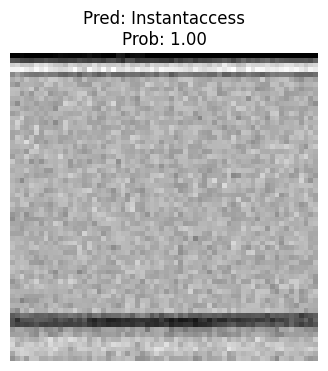

In [16]:
# ============================================================
# 17. 신규 악성코드 이미지 1건 패밀리 예측
# ============================================================

# 평가 데이터 중 몇 번째 이미지를 사용할지 인덱스를 지정합니다.
# 0은 첫 번째 평가 이미지를 뜻합니다.
idx = 0

# X_test에서 idx번째 이미지 한 장을 가져옵니다.
sample_img = X_test[idx]

# 같은 위치의 실제 정답 숫자 라벨을 가져옵니다.
sample_true = y_test[idx]

# sample_img 한 장의 원래 모양은 (64, 64, 1)입니다.
# 모델은 첫 번째 차원에 배치 크기가 있어야 하므로
# reshape를 이용해 (1, 64, 64, 1)로 바꿉니다.
# model.predict는 모든 클래스의 예측 확률을 반환합니다.
# [0]은 배치에 이미지가 한 장뿐이므로 첫 번째 결과만 꺼낸다는 뜻입니다.
prob = model.predict(sample_img.reshape(1, IMG_SIZE, IMG_SIZE, 1))[0]

# 클래스별 확률 중 가장 큰 값의 위치를 최종 예측 클래스 번호로 선택합니다.
pred_idx = np.argmax(prob)

# 예측 클래스 번호를 실제 악성코드 패밀리 이름으로 변환합니다.
pred_family = class_names[pred_idx]

# 실제 정답 숫자 라벨도 실제 악성코드 패밀리 이름으로 변환합니다.
true_family = class_names[sample_true]

# 최종 예측 패밀리에 해당하는 확률값을 가져옵니다.
pred_prob = prob[pred_idx]

# 예측 결과 출력의 제목을 표시합니다.
print("[신규 악성코드 이미지 패밀리 분류 결과]")

# 이미지의 실제 악성코드 패밀리를 출력합니다.
print("실제 패밀리:", true_family)

# 모델이 예측한 악성코드 패밀리를 출력합니다.
print("예측 패밀리:", pred_family)

# 0~1 범위 확률에 100을 곱해 백분율로 바꿉니다.
# float로 일반 실수형으로 변환한 뒤 소수점 둘째 자리까지 반올림합니다.
print("예측 확률:", round(float(pred_prob) * 100, 2), "%")

# 선택한 이미지 한 장을 보여줄 4×4인치 그림판을 만듭니다.
plt.figure(figsize=(4, 4))

# 이미지의 마지막 채널 차원을 제거해 64×64 모양으로 출력합니다.
# cmap="gray"는 흑백 이미지로 표시한다는 뜻입니다.
plt.imshow(sample_img.reshape(IMG_SIZE, IMG_SIZE), cmap="gray")

# 그래프 제목에 예측 패밀리와 예측 확률을 표시합니다.
# \n은 제목 안에서 줄을 바꾸는 문자입니다.
# :.2f는 확률을 소수점 둘째 자리까지 표시합니다.
plt.title(f"Pred: {pred_family}\nProb: {pred_prob:.2f}")

# 이미지 주변의 축과 눈금을 숨깁니다.
plt.axis("off")

# 완성된 예측 이미지를 화면에 출력합니다.
plt.show()
